# Hyperparameters experimenting stable-baselines - Experiments on one agent using PettingZoo

In this notebook, different values of the gamma and learning_rate hyperparameters are being examined during the learning process.

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import matplotlib.pyplot as plt
import numpy as np

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [271.43460132946416, 104.70146713768442, 6.1187751846598974], (0, 1): [371.9491578317114, 211.2923507435373, 64.86805604624895], (1, 0): [784.7429938025994, 14.264416005888508, 3.0272454454536435], (1, 1): [63.15166418050102, 643.5141994749899, 405.38261572944276]}
[SUCCESS] Free flow times calculated!
[SUCCESS]: The vehicle will travel from origin  [1]  to destination. [1]  This path has free flow travel time:  [63.15166418050102, 643.5141994749899, 405.38261572944276]


In [5]:
env.reset()
env.reward_table = []

In [6]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

### Gamma

In [7]:
# Define the parameter ranges you want to test
gamma_range = np.linspace(0.85, 0.975, 10) 

Reward table is:  [-513.75, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -513.75, -80.3, -513.75, -849.25, -80.3, -513.75, -513.75, -80.3, -849.25, -513.75, -80.3, -849.25, -849.25, -80.3, -513.75, -513.75, -849.25, -849.25, -849.25, -80.3, -80.3, -80.3, -849.25, -849.25, -80.3, -513.75, -849.25, -513.75, -80.3, -849.25, -513.75, -849.25, -80.3, -80.3, -80.3, -513.75, -849.25, -849.25, -513.75, -513.75, -849.25, -849.25, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -513.75, -849.25, -849.25, -513.75, -849.25, -513.75, -849.25, -80.3, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25, -513.75, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -849.25, -513.75, -513.75, -80.3, -513.75, -513.75, -513.75, -80.3, -513.75, -513.75, -849.25, -513.75, -80.3, -513.75]
Actions are:  [2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 1, 0, 2, 2, 0, 1, 2, 0, 1, 1, 0, 2, 2, 1, 1, 1, 0, 0, 0, 1, 1, 0, 2, 1, 2, 0, 1, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 1, 1, 

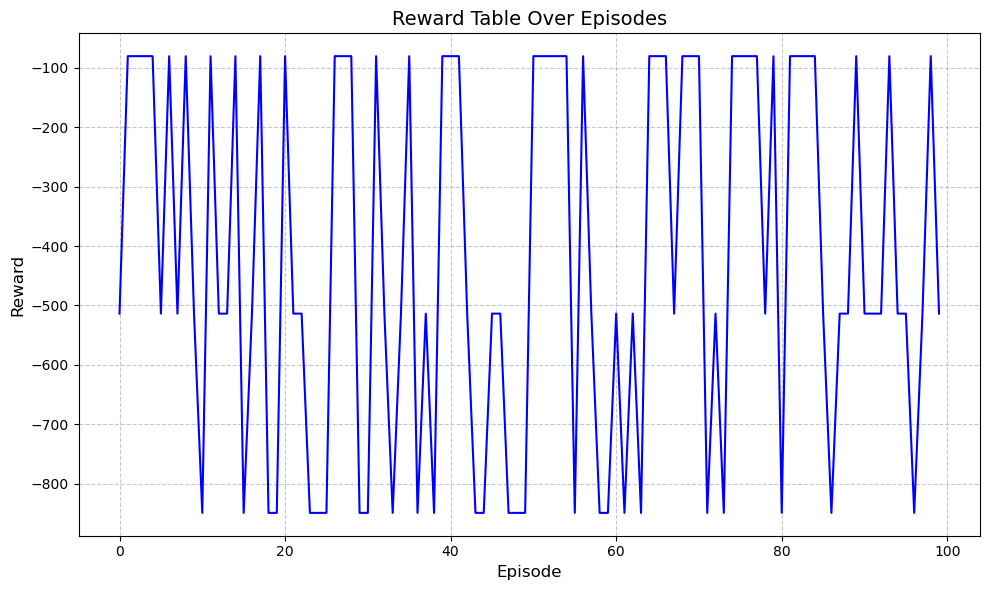

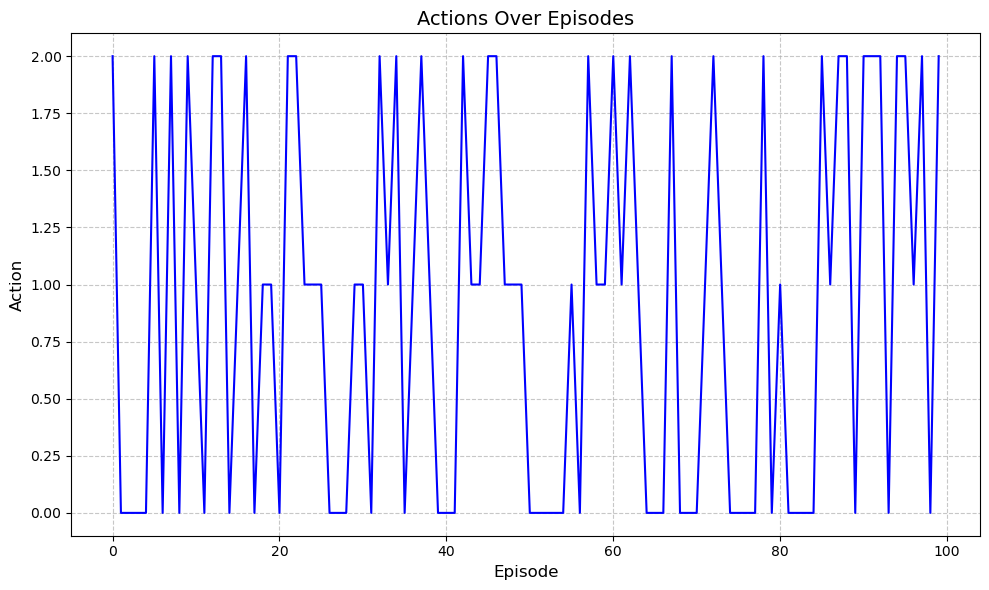

Reward table is:  [-513.75, -80.3, -849.25, -849.25, -513.75, -849.25, -80.3, -513.75, -849.25, -513.75, -513.75, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -849.25, -80.3, -849.25, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -849.25, -513.75, -80.3, -849.25, -513.75, -849.25, -80.3, -513.75, -80.3, -513.75, -513.75, -849.25, -513.75, -80.3, -849.25, -513.75, -80.3, -513.75, -513.75, -513.75, -513.75, -849.25, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -513.75, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -513.75, -513.75, -513.75, -849.25, -849.25, -849.25, -849.25, -80.3, -513.75, -849.25, -80.3, -513.75, -513.75, -849.25, -80.3, -80.3, -849.25, -849.25, -80.3, -80.3, -80.3, -849.25, -513.75, -80.3, -80.3, -513.75, -80.3, -849.25, -80.3, -80.3, -80.3, -849.25]
Actions are:  [2, 0, 1, 1, 2, 1, 0, 2, 1, 2, 2, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 1, 0, 2, 0, 2, 2, 1, 2, 0, 1, 2, 0, 2, 2, 2, 2, 1,

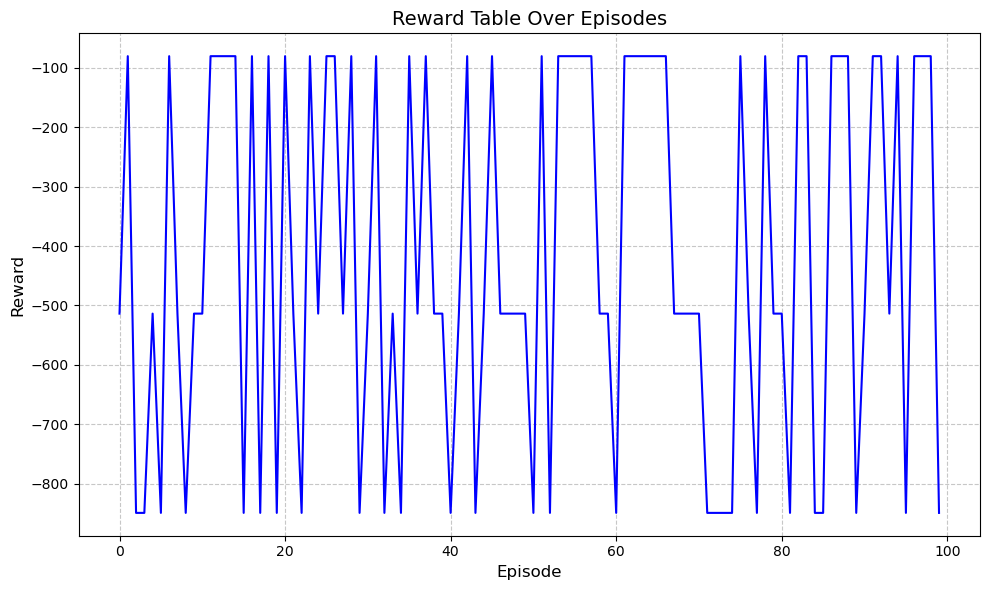

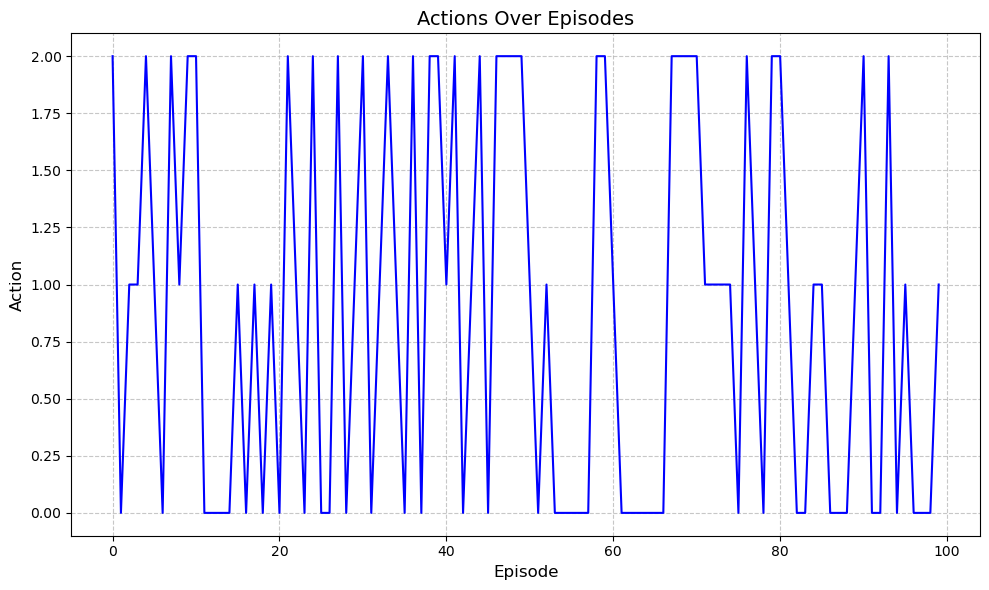

Reward table is:  [-849.25, -849.25, -513.75, -80.3, -513.75, -513.75, -849.25, -513.75, -513.75, -513.75, -849.25, -513.75, -513.75, -849.25, -80.3, -80.3, -849.25, -80.3, -513.75, -513.75, -849.25, -80.3, -513.75, -849.25, -80.3, -80.3, -849.25, -80.3, -513.75, -513.75, -849.25, -849.25, -513.75, -80.3, -80.3, -513.75, -80.3, -849.25, -849.25, -513.75, -513.75, -80.3, -80.3, -80.3, -849.25, -80.3, -513.75, -513.75, -513.75, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -80.3, -849.25, -849.25, -80.3, -80.3, -80.3, -513.75, -513.75, -80.3, -513.75, -513.75, -849.25, -849.25, -80.3, -849.25, -513.75, -80.3, -849.25, -849.25, -849.25, -513.75, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25, -513.75, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3]
Actions are:  [1, 1, 2, 0, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 0, 0, 1, 0, 2, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 2, 1, 1, 2, 0, 0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 2, 2, 2, 0, 2,

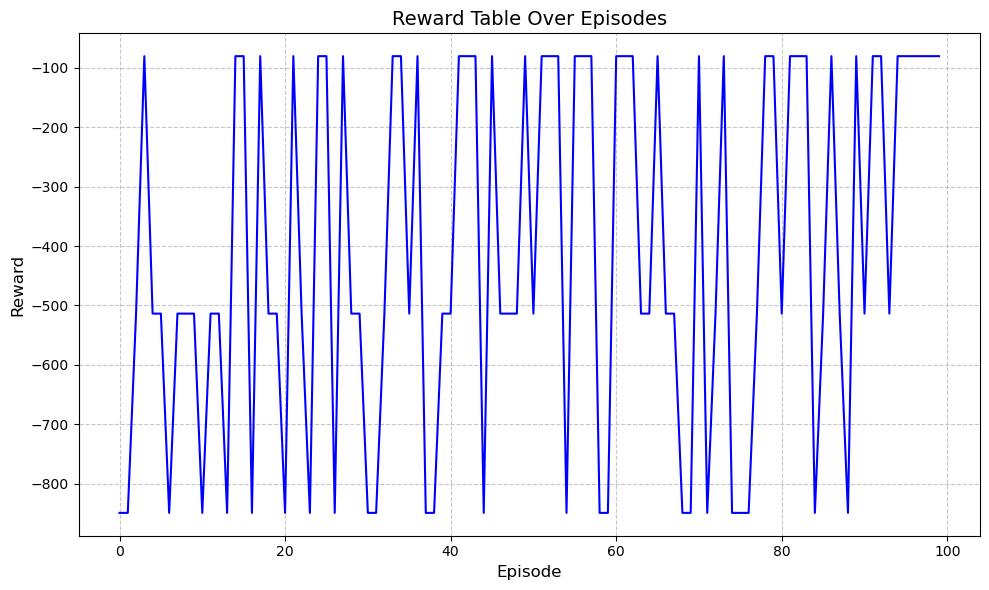

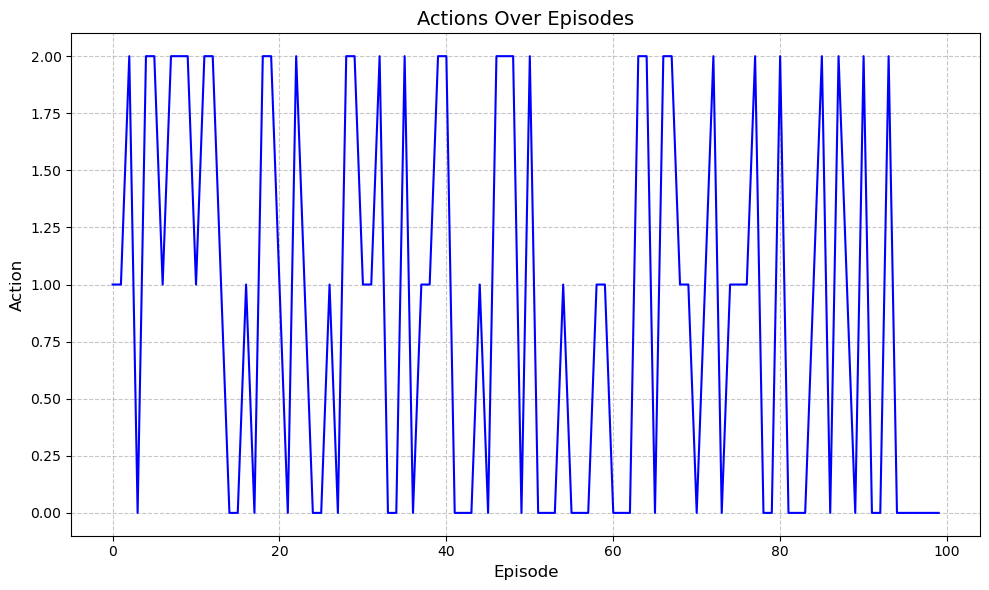

Reward table is:  [-849.25, -849.25, -80.3, -849.25, -80.3, -849.25, -80.3, -513.75, -80.3, -513.75, -849.25, -849.25, -849.25, -80.3, -80.3, -849.25, -849.25, -513.75, -849.25, -513.75, -513.75, -513.75, -849.25, -849.25, -849.25, -80.3, -513.75, -849.25, -849.25, -80.3, -80.3, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -849.25, -80.3, -80.3, -80.3, -513.75, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -513.75, -80.3, -513.75, -80.3, -513.75, -513.75, -513.75, -80.3, -80.3, -513.75, -513.75, -513.75, -80.3, -80.3, -80.3, -849.25, -849.25, -80.3, -513.75, -513.75, -80.3, -849.25, -849.25, -80.3, -513.75, -513.75, -849.25, -513.75, -513.75, -513.75, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -849.25, -80.3, -849.25, -849.25, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3]
Actions are:  [1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 2, 2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 0, 1, 0

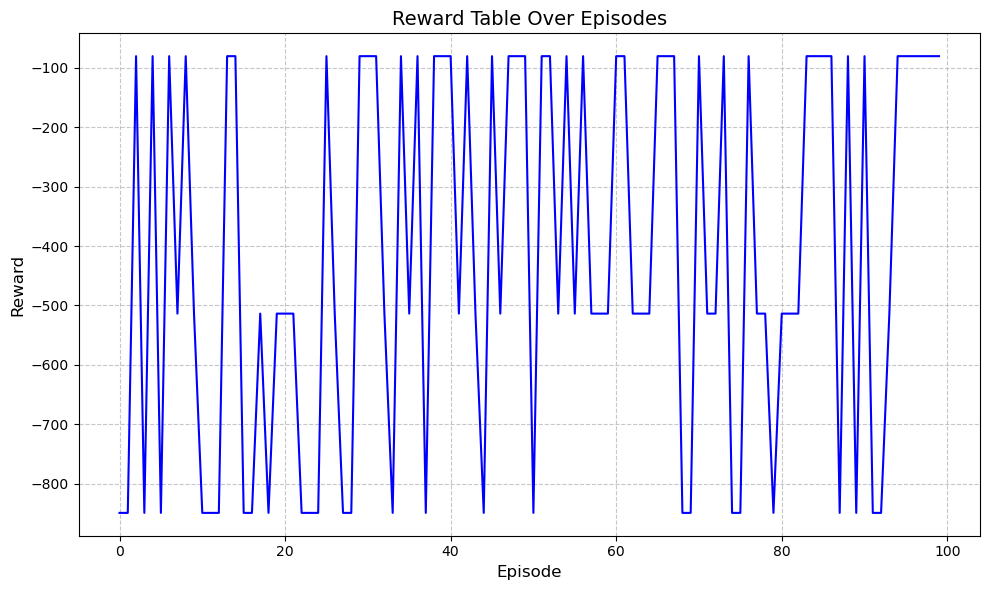

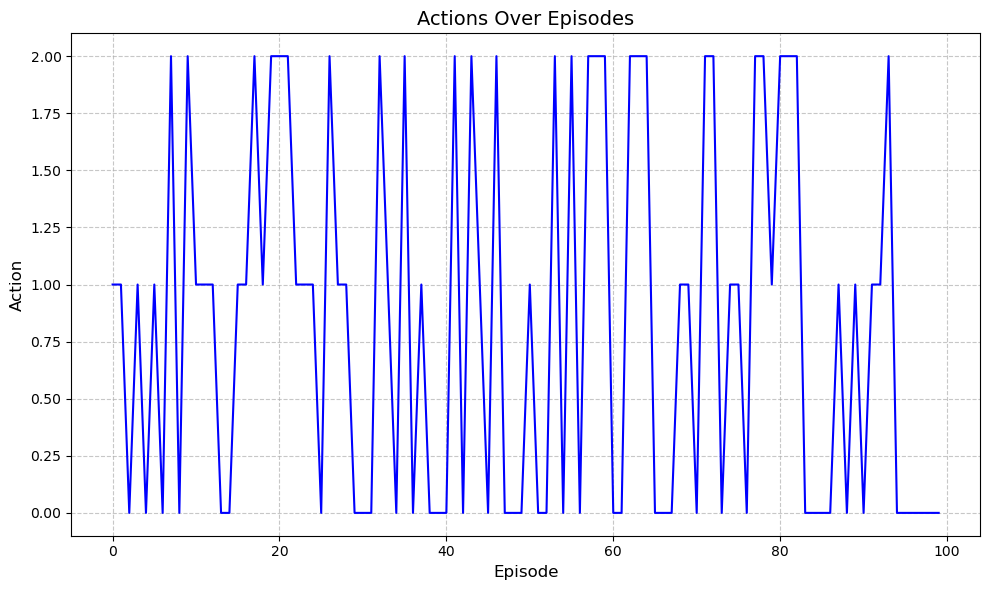

Reward table is:  [-849.25, -513.75, -513.75, -513.75, -513.75, -513.75, -849.25, -80.3, -849.25, -513.75, -513.75, -513.75, -849.25, -80.3, -513.75, -849.25, -513.75, -513.75, -849.25, -513.75, -80.3, -80.3, -849.25, -80.3, -513.75, -849.25, -513.75, -849.25, -513.75, -849.25, -513.75, -849.25, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -513.75, -80.3, -513.75, -80.3, -513.75, -513.75, -849.25, -80.3, -80.3, -513.75, -849.25, -80.3, -513.75, -513.75, -80.3, -513.75, -849.25, -80.3, -513.75, -80.3, -513.75, -80.3, -849.25, -849.25, -80.3, -80.3, -849.25, -80.3, -513.75, -849.25, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -849.25, -849.25, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -513.75, -513.75, -80.3, -849.25, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25]
Actions are:  [1, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2, 2, 1, 0, 2, 1, 2, 2, 1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 2, 1, 0, 0, 2, 1, 0

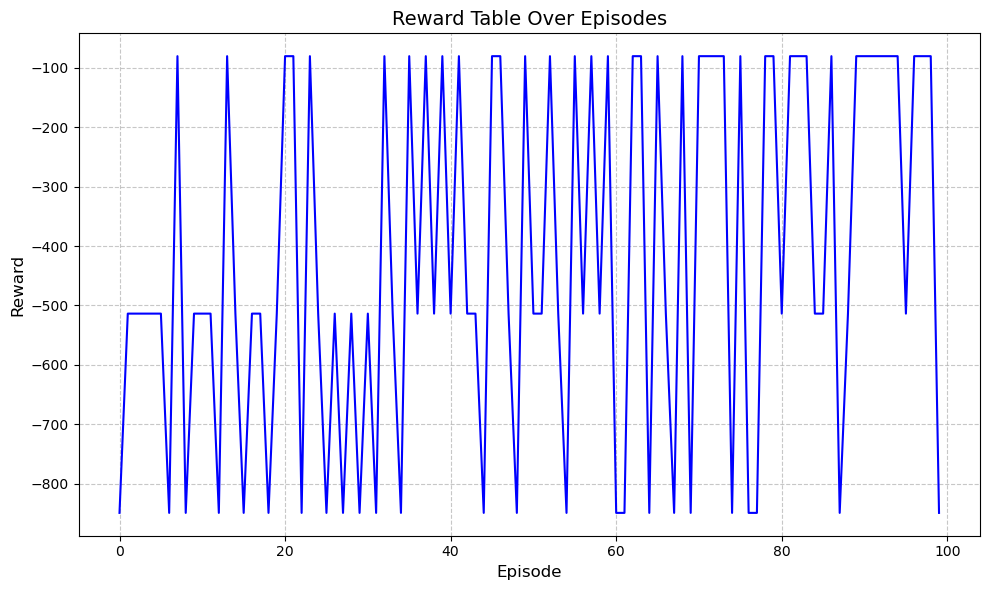

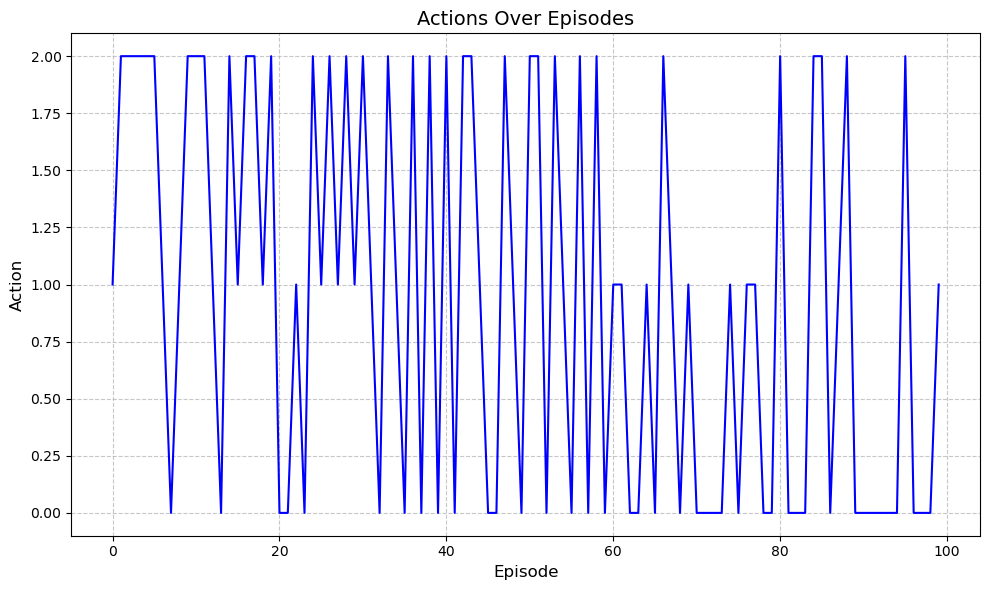

Reward table is:  [-513.75, -513.75, -513.75, -849.25, -513.75, -513.75, -849.25, -80.3, -80.3, -849.25, -849.25, -849.25, -849.25, -80.3, -80.3, -513.75, -80.3, -849.25, -849.25, -80.3, -849.25, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -513.75, -80.3, -849.25, -80.3, -513.75, -513.75, -513.75, -513.75, -80.3, -80.3, -849.25, -80.3, -80.3, -513.75, -80.3, -80.3, -849.25, -80.3, -849.25, -849.25, -513.75, -849.25, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -513.75, -849.25, -80.3, -80.3, -80.3, -80.3, -849.25, -513.75, -80.3, -80.3, -80.3, -849.25, -849.25, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -849.25, -849.25, -80.3, -80.3, -80.3, -513.75, -80.3, -849.25, -80.3, -513.75, -513.75, -80.3, -80.3, -849.25, -849.25, -80.3, -513.75, -80.3, -80.3, -80.3, -513.75, -849.25, -849.25, -80.3, -80.3, -80.3]
Actions are:  [2, 2, 2, 1, 2, 2, 1, 0, 0, 1, 1, 1, 1, 0, 0, 2, 0, 1, 1, 0, 1, 0, 2, 0, 0, 2, 0, 2, 0, 1, 0, 2, 2, 2, 2, 0, 0, 1, 0, 0, 2, 0, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0, 2,

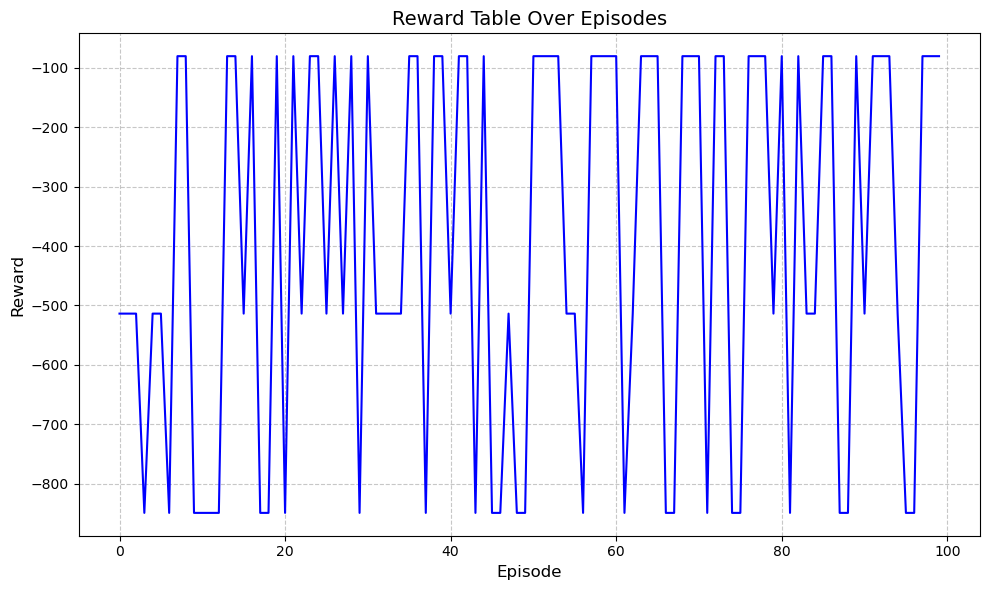

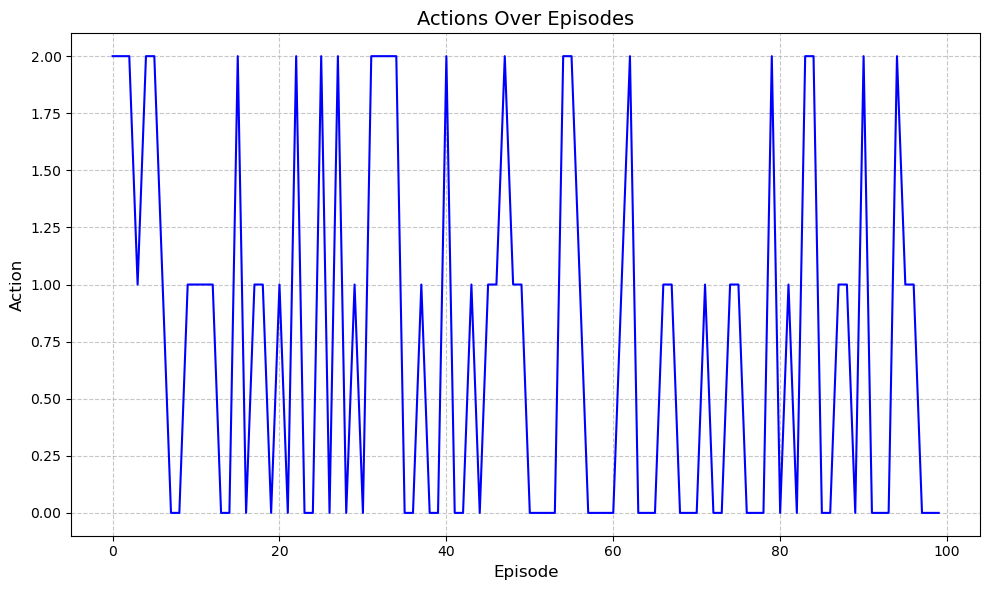

Reward table is:  [-80.3, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -849.25, -80.3, -513.75, -513.75, -513.75, -80.3, -849.25, -513.75, -849.25, -80.3, -849.25, -849.25, -513.75, -849.25, -80.3, -80.3, -849.25, -80.3, -513.75, -80.3, -80.3, -849.25, -849.25, -849.25, -849.25, -80.3, -80.3, -80.3, -513.75, -849.25, -513.75, -849.25, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -849.25, -513.75, -80.3, -849.25, -80.3, -80.3, -513.75, -849.25, -80.3, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -80.3, -849.25, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3]
Actions are:  [0, 0, 2, 0, 0, 2, 0, 0, 0, 1, 0, 2, 2, 2, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 2, 1, 0, 0, 2, 0, 0, 

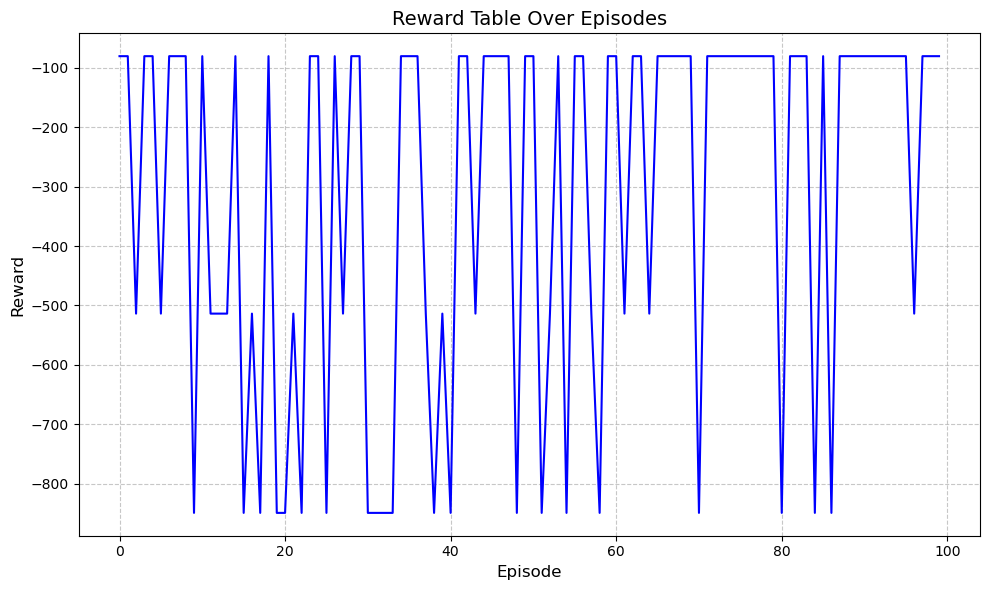

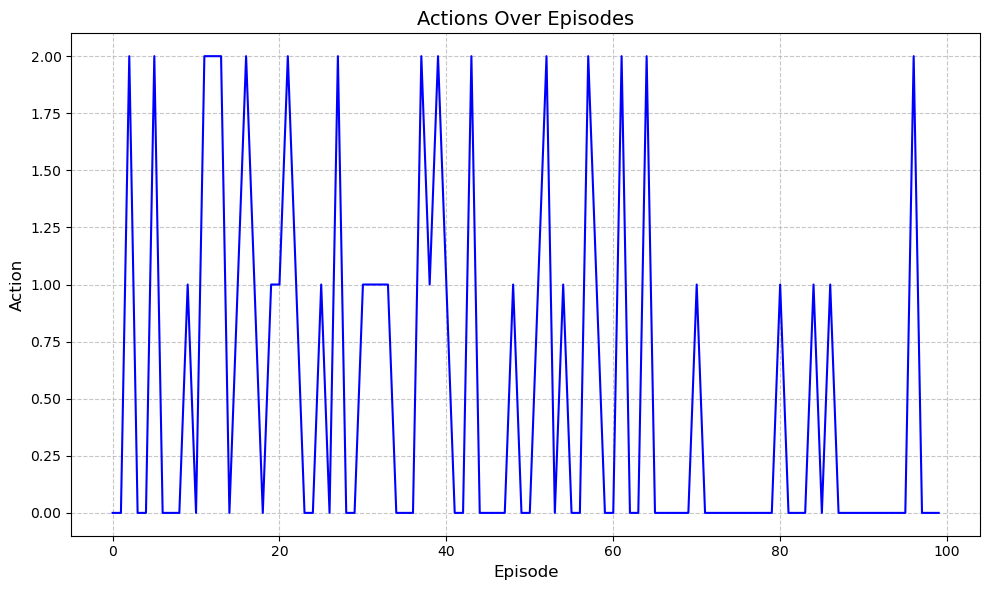

Reward table is:  [-80.3, -80.3, -849.25, -513.75, -513.75, -80.3, -513.75, -80.3, -849.25, -513.75, -513.75, -80.3, -849.25, -513.75, -849.25, -849.25, -849.25, -513.75, -849.25, -849.25, -849.25, -849.25, -80.3, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -849.25, -80.3, -513.75, -849.25, -80.3, -849.25, -80.3, -80.3, -849.25, -80.3, -849.25, -513.75, -80.3, -513.75, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -513.75, -849.25, -513.75, -80.3, -80.3, -80.3, -80.3, -513.75, -849.25, -849.25, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -849.25, -849.25, -80.3, -80.3, -80.3, -849.25, -513.75, -513.75, -80.3, -513.75, -80.3, -80.3, -513.75, -849.25, -80.3, -80.3, -80.3, -513.75, -513.75, -513.75, -849.25, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3]
Actions are:  [0, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 0, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 1, 2, 0,

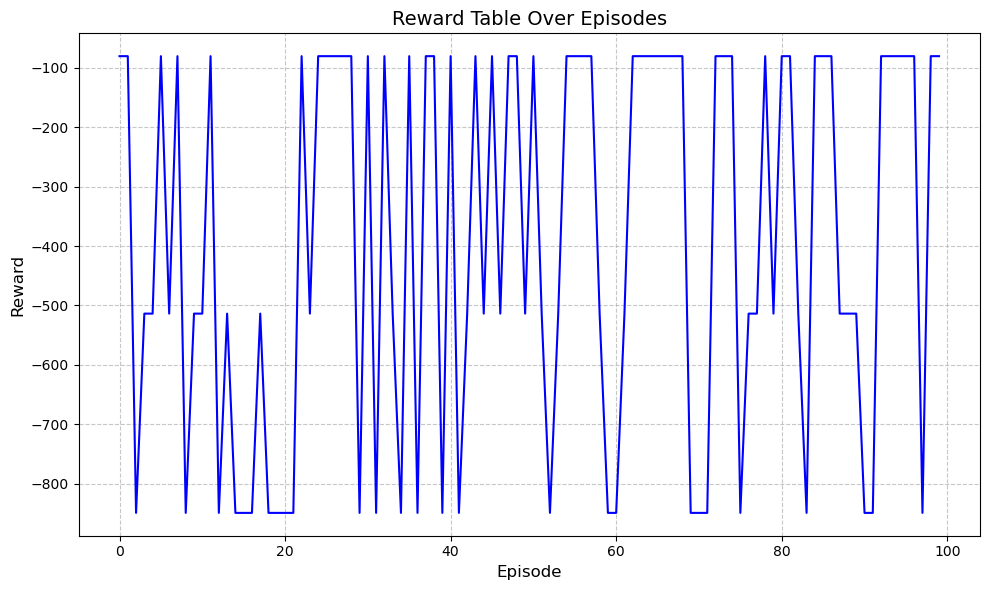

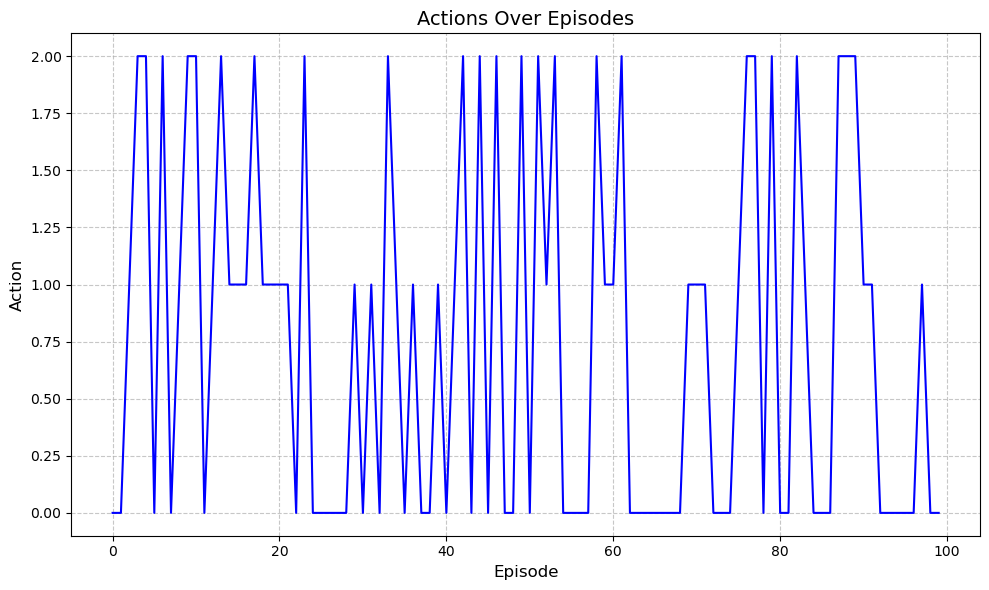

Reward table is:  [-849.25, -80.3, -849.25, -513.75, -80.3, -513.75, -513.75, -513.75, -513.75, -513.75, -80.3, -513.75, -80.3, -80.3, -849.25, -80.3, -80.3, -513.75, -513.75, -513.75, -513.75, -849.25, -80.3, -80.3, -80.3, -513.75, -80.3, -849.25, -80.3, -80.3, -849.25, -513.75, -80.3, -80.3, -80.3, -513.75, -849.25, -849.25, -80.3, -513.75, -80.3, -513.75, -80.3, -80.3, -80.3, -80.3, -513.75, -513.75, -513.75, -80.3, -513.75, -849.25, -80.3, -513.75, -849.25, -80.3, -80.3, -80.3, -513.75, -513.75, -80.3, -849.25, -80.3, -80.3, -80.3, -513.75, -513.75, -80.3, -80.3, -849.25, -849.25, -849.25, -80.3, -513.75, -80.3, -849.25, -80.3, -849.25, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -849.25, -513.75, -80.3, -849.25, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3]
Actions are:  [1, 0, 1, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0, 1, 0, 0, 2, 2, 2, 2, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 2, 0, 0, 0, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 1, 0, 2, 1, 0, 

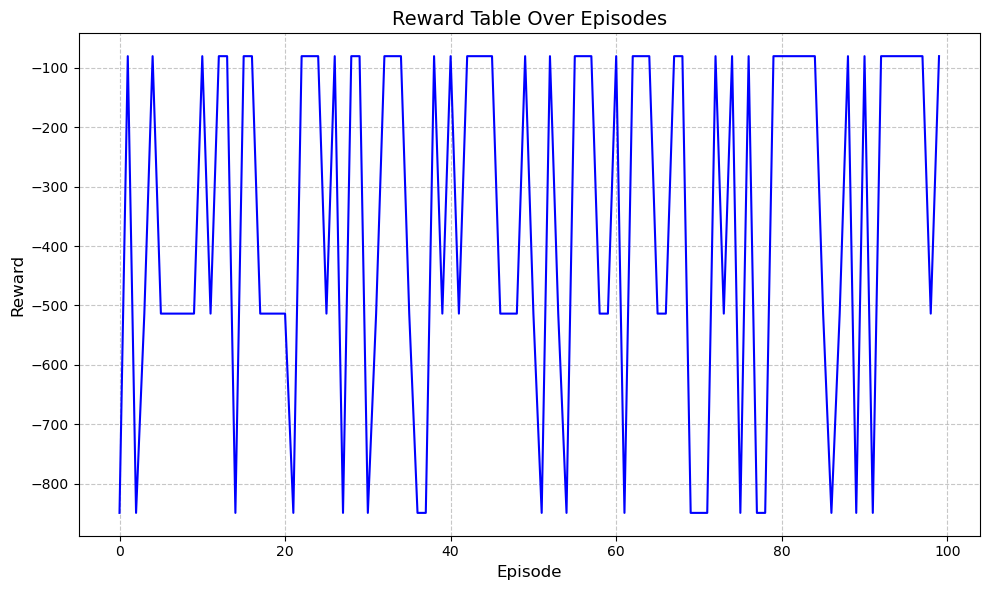

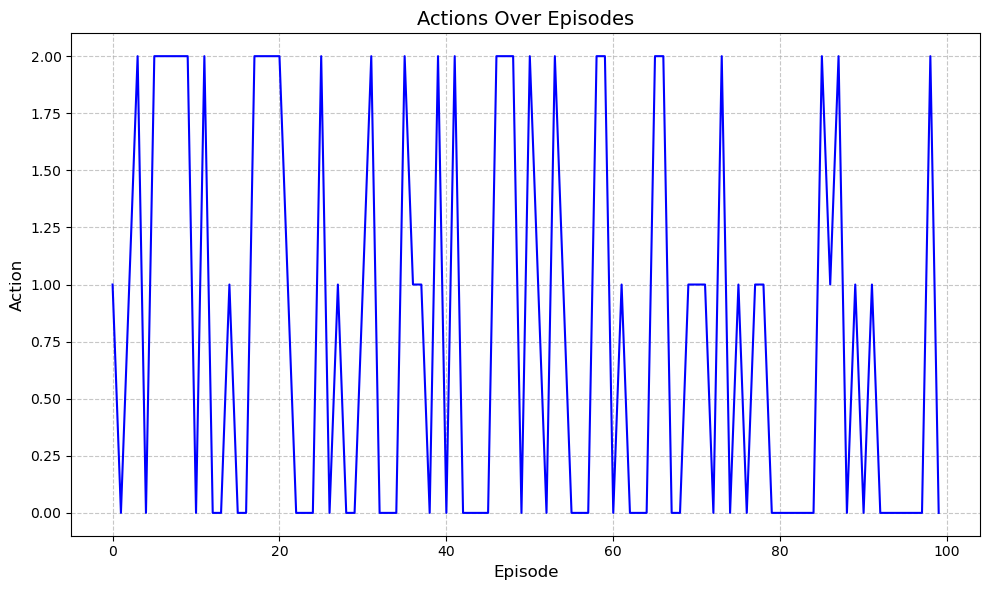

Reward table is:  [-849.25, -849.25, -849.25, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -513.75, -513.75, -513.75, -513.75, -849.25, -849.25, -849.25, -849.25, -80.3, -849.25, -849.25, -849.25, -80.3, -80.3, -849.25, -513.75, -849.25, -513.75, -513.75, -80.3, -80.3, -80.3, -80.3, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -80.3, -80.3, -513.75, -849.25, -80.3, -849.25, -513.75, -513.75, -80.3, -80.3, -849.25, -80.3, -80.3, -80.3, -80.3, -513.75, -80.3, -513.75, -513.75, -80.3, -513.75, -513.75, -513.75, -80.3, -849.25, -80.3, -849.25, -80.3, -513.75, -80.3, -80.3, -513.75, -80.3, -513.75, -513.75, -513.75, -513.75, -80.3, -80.3, -80.3, -513.75, -80.3, -80.3, -849.25, -80.3, -513.75, -80.3, -849.25, -513.75, -80.3, -513.75, -849.25, -79.33333333333333, -79.33333333333333, -1334.8, -79.33333333333333, -49.38333333333333, -49.38333333333333, -49.38333333333333, -79.33333333333333]
Actions are:  [1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 2

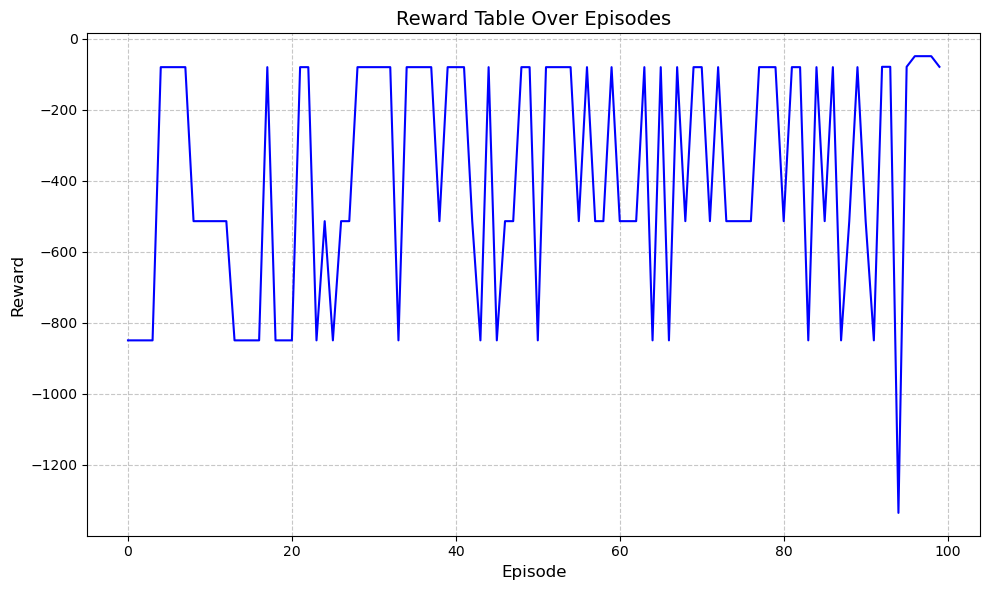

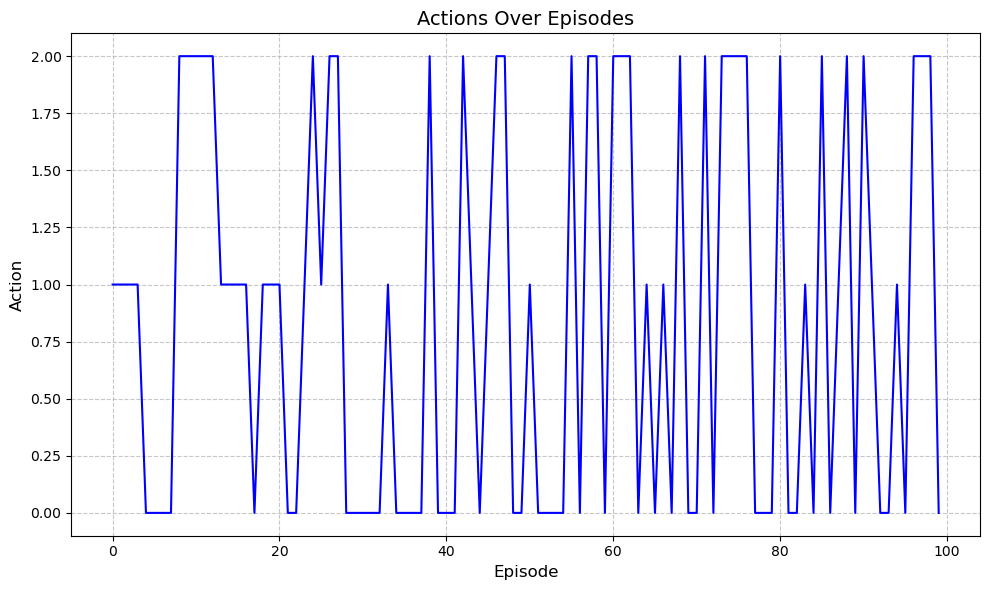

In [8]:
for gamma in gamma_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": 1e-3,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=0, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    model.learn(total_timesteps=100)  # Example: 20 total timesteps

    env.close()

### Learning Rate

In [9]:
learning_rate_range = np.linspace(1e-4, 1e-2, 10)  # Example range for learning_rate
gamma = 0.95  # Constant value for gamma

Reward table is:  [-1090.05, -138.35, -138.35, -138.35, -1090.05, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -1090.05, -138.35, -111.36666666666666, -1090.05, -138.35, -1090.05, -138.35, -138.35, -138.35, -111.36666666666666, -1090.05, -138.35, -1090.05, -1090.05, -111.36666666666666, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -1090.05, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -1090.05, -138.35, -138.35, -111.36666666666666, -1090.05, -1090.05, -111.36666666666666, -1090.05, -1090.05, -111.36666666666666, -1090.05, -1090.05, -1090.05, -1090.05, -1090.05, -138.35, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -1090.05, -111.36666666666666, -111.36666666666666, -1090.05, -1

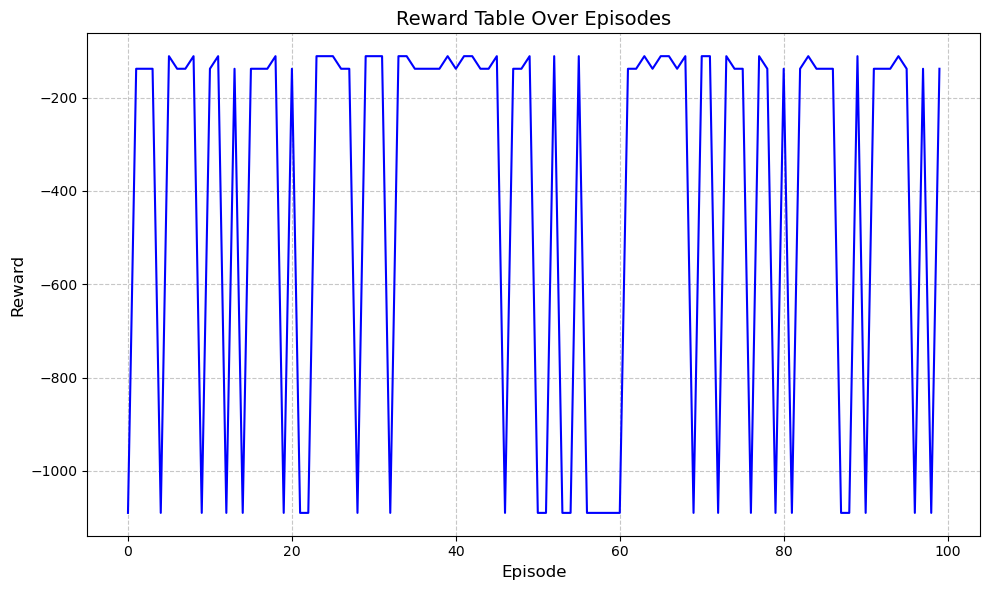

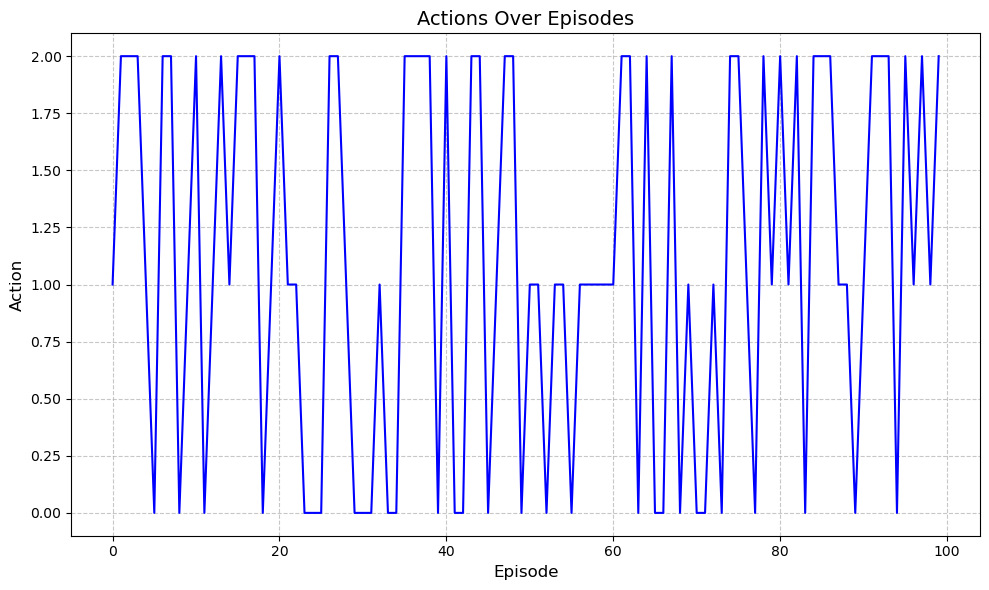

Reward table is:  [-111.36666666666666, -1090.05, -111.36666666666666, -1090.05, -111.36666666666666, -1090.05, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -1090.05, -138.35, -1090.05, -1090.05, -138.35, -138.35, -1090.05, -1090.05, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -1090.05, -1090.05, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -1090.05, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -1090.05, -1090.05, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -138

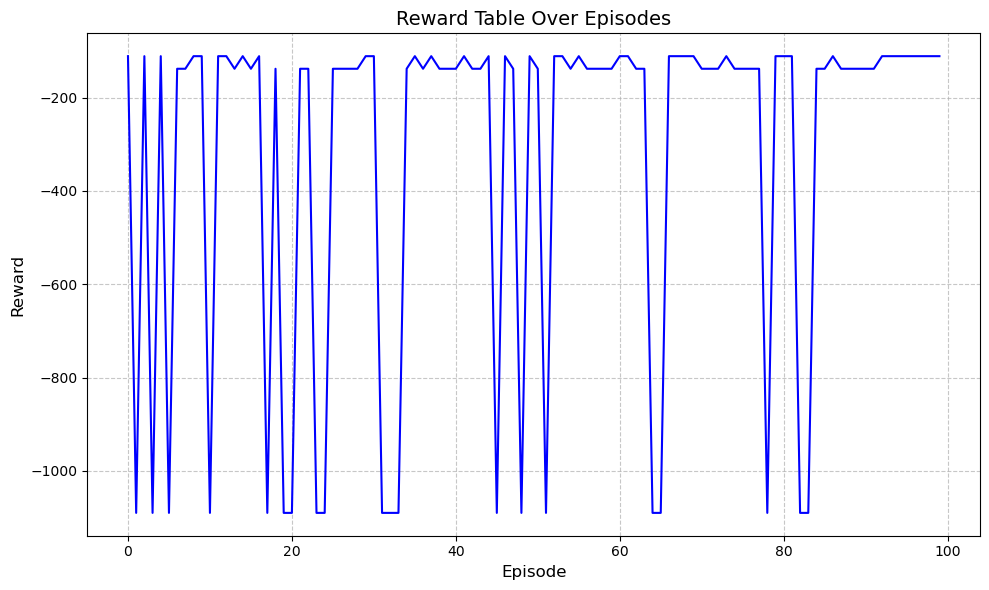

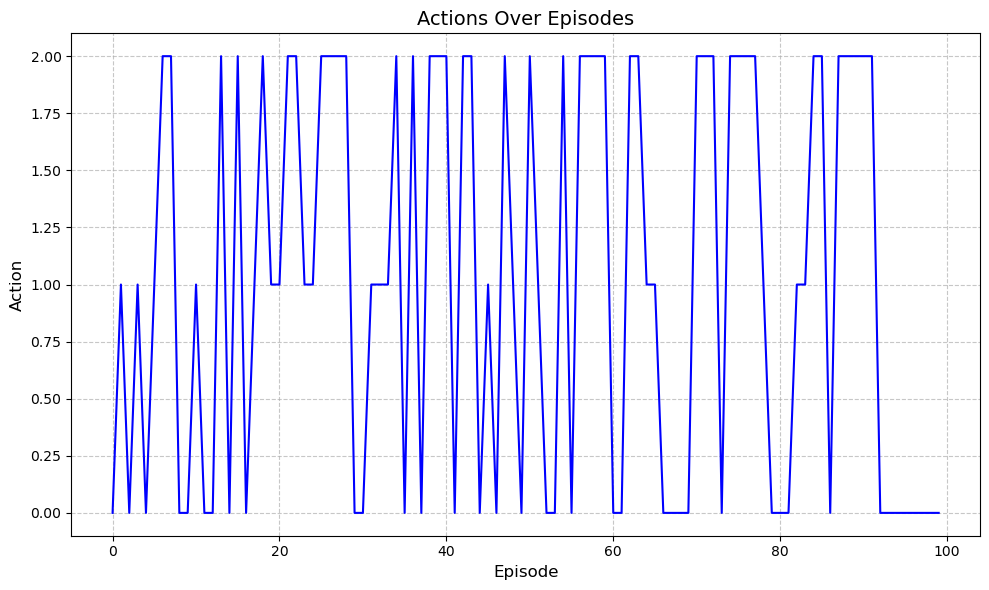

Reward table is:  [-1090.05, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -1090.05, -138.35, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -138.35, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -1090.05, -138.35, -1090.05, -1090.05, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -1090.05, -1090.05, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -

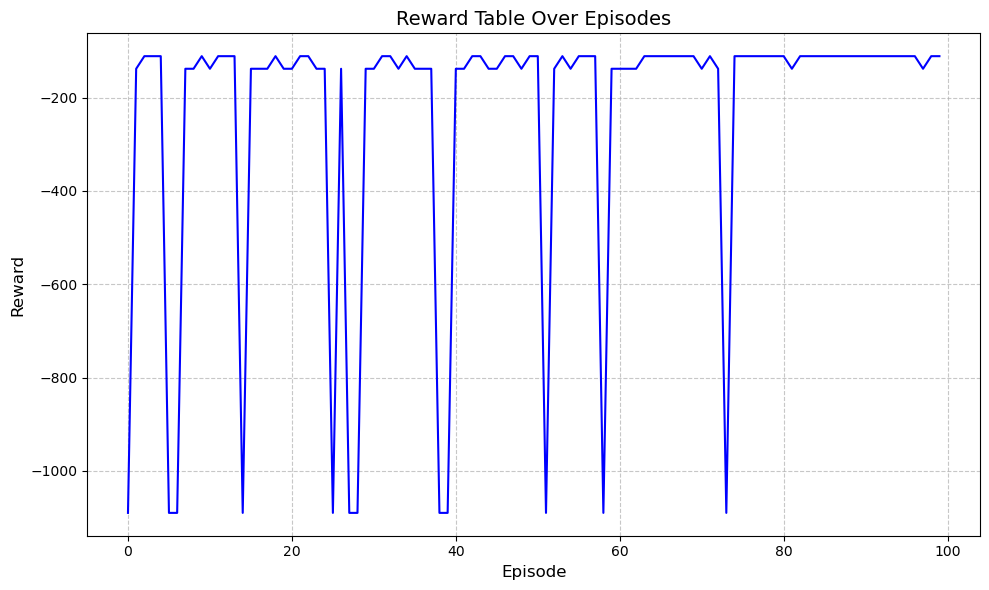

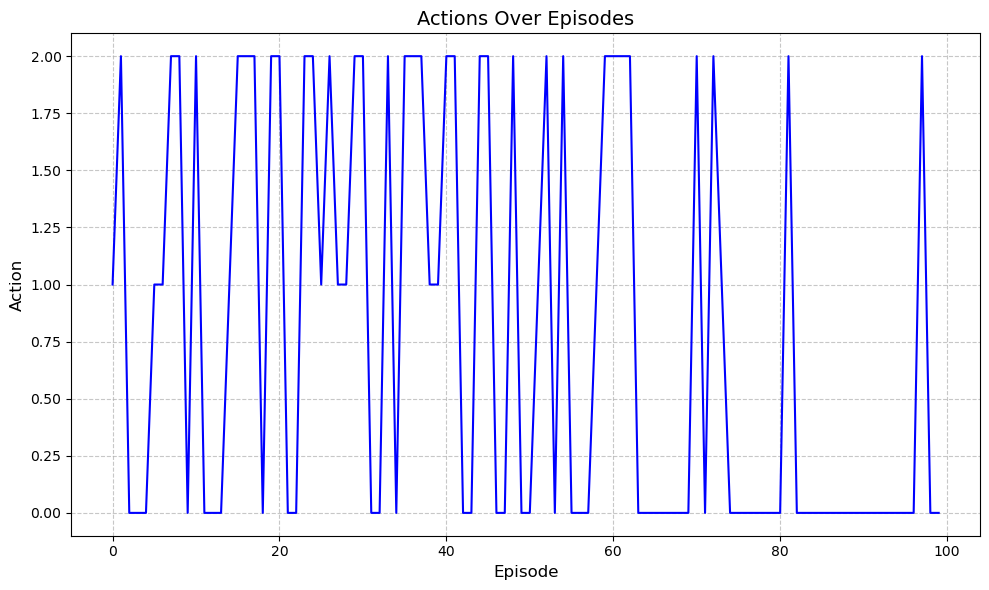

Reward table is:  [-138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -1090.05, -138.35, -111.36666666666666, -138.35, -138.35, -1090.05, -1090.05, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -1090.05, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -1090.05, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -138.35, -111.3666666666

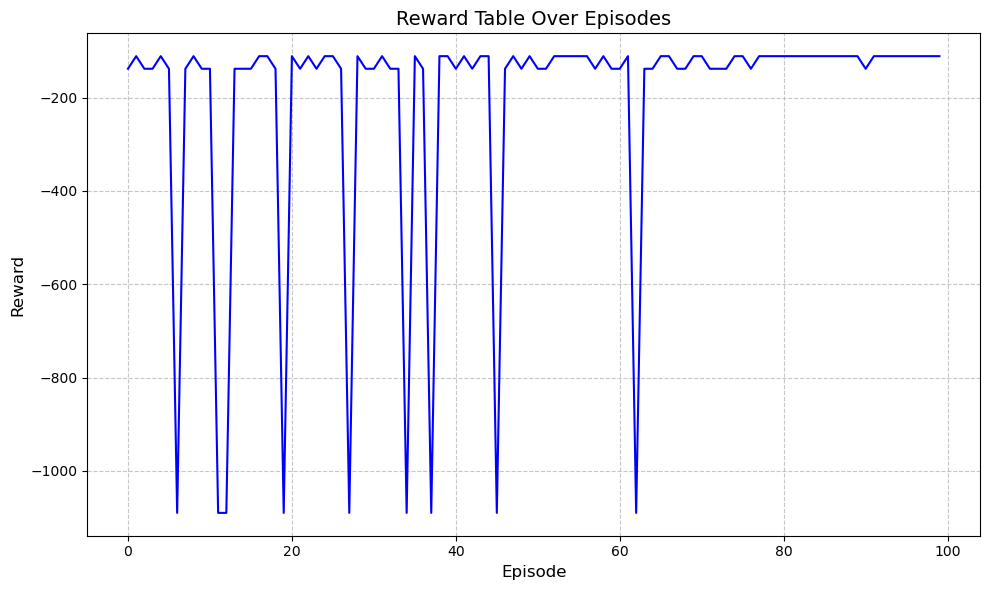

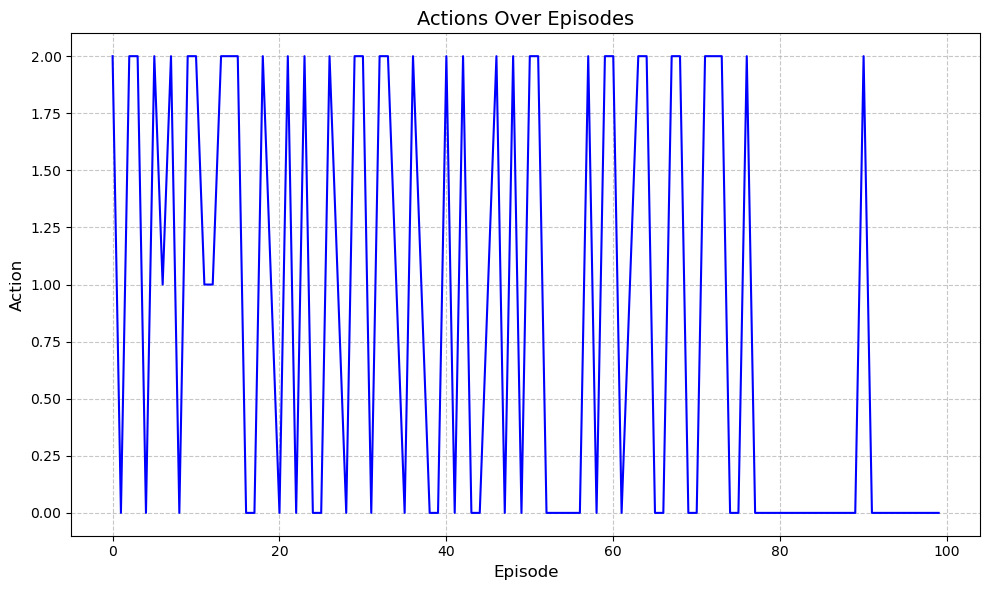

Reward table is:  [-1090.05, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -1090.05, -1090.05, -138.35, -138.35, -1090.05, -138.35, -111.36666666666666, -1090.05, -111.36666666666666, -138.35, -1090.05, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.366

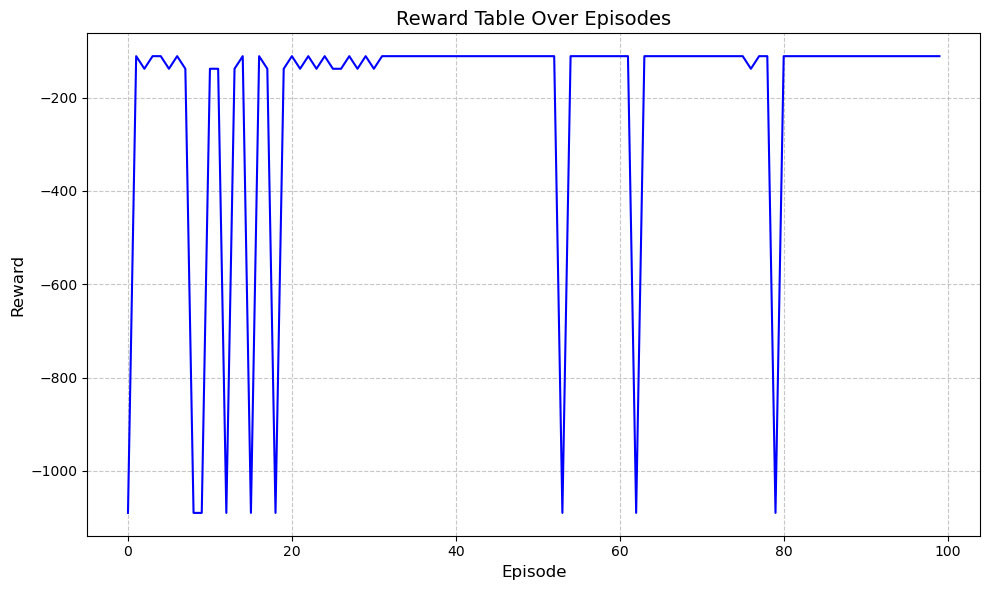

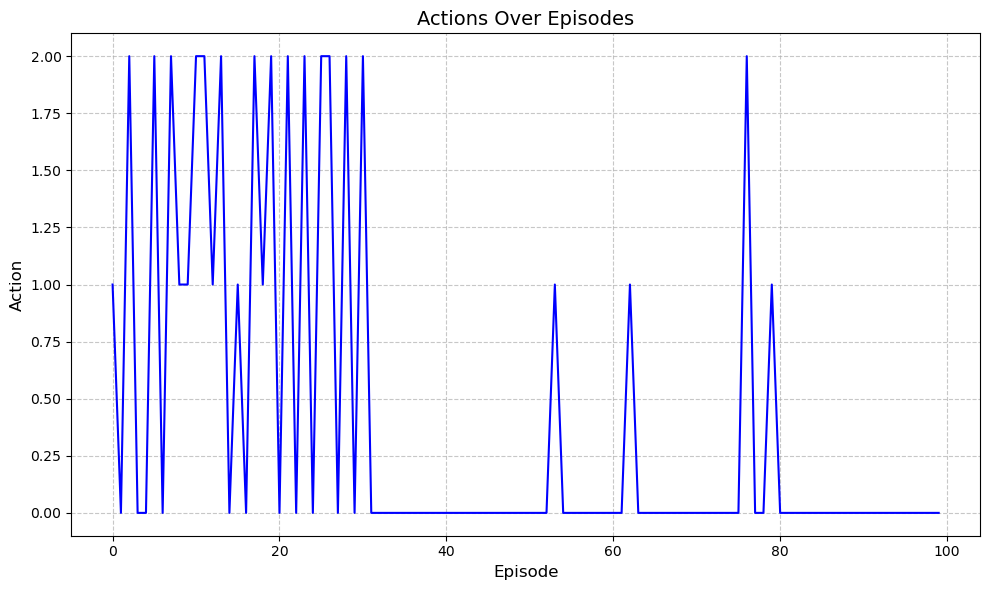

Reward table is:  [-138.35, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -111.36666666666666, -111.36666666666666, -138.35, -1090.05, -1090.05, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -1090.05, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -1090.05, -111.36666666666666, -1090.05, -1090.05, -1090.05, -111.36666666666666, -138.35, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666

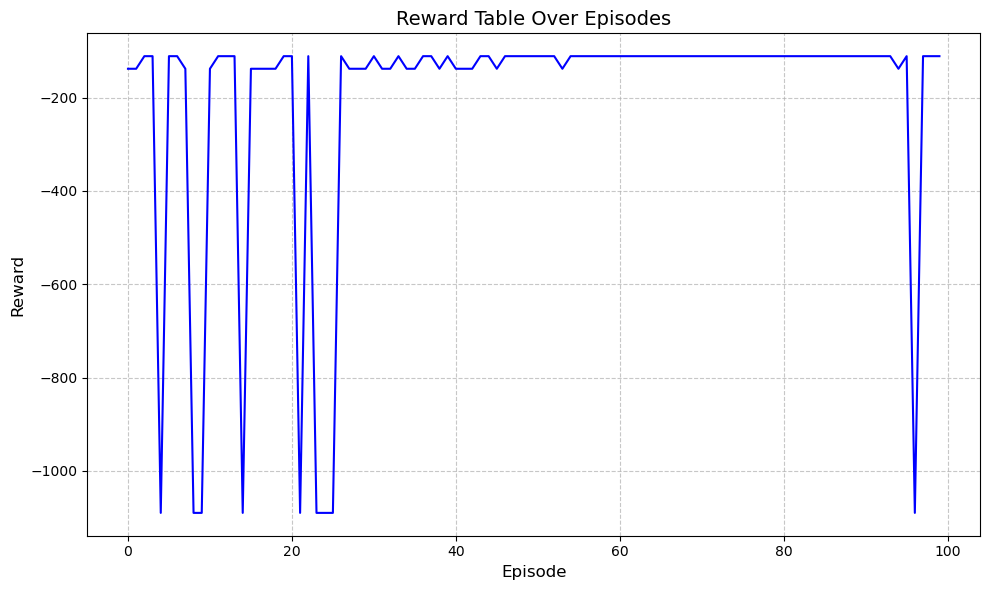

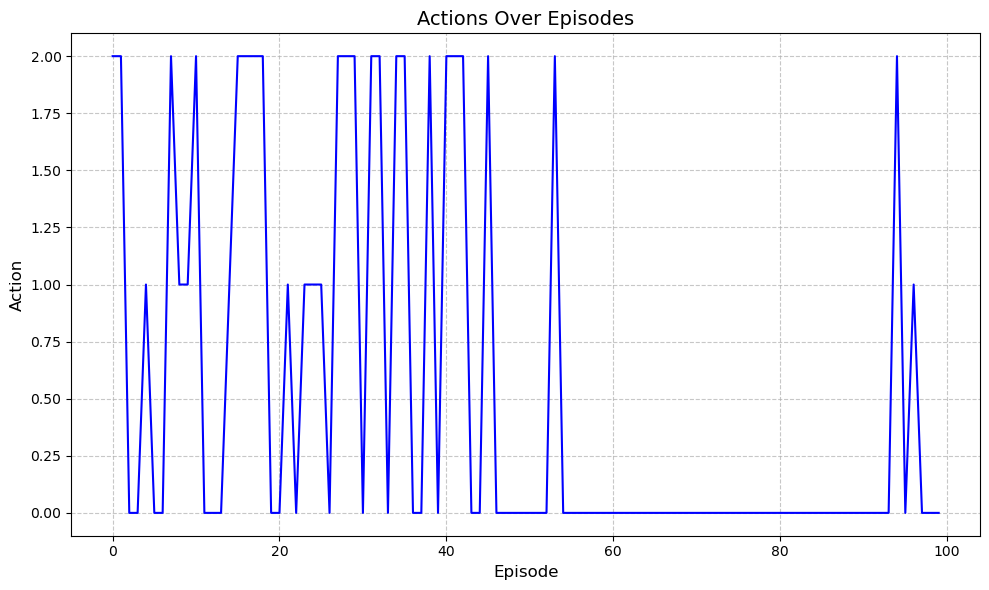

Reward table is:  [-1090.05, -1090.05, -138.35, -111.36666666666666, -1090.05, -138.35, -111.36666666666666, -1090.05, -138.35, -1090.05, -1090.05, -138.35, -1090.05, -111.36666666666666, -138.35, -1090.05, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -1090.05, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -138.35, -1090.05, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -1090.05, -138.35, -138.35, -138.35, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -111.36666666666666, -138.35, -111.36666666666666, -111.36666666666666, -111.36666666666666, -111.36666666666666, -

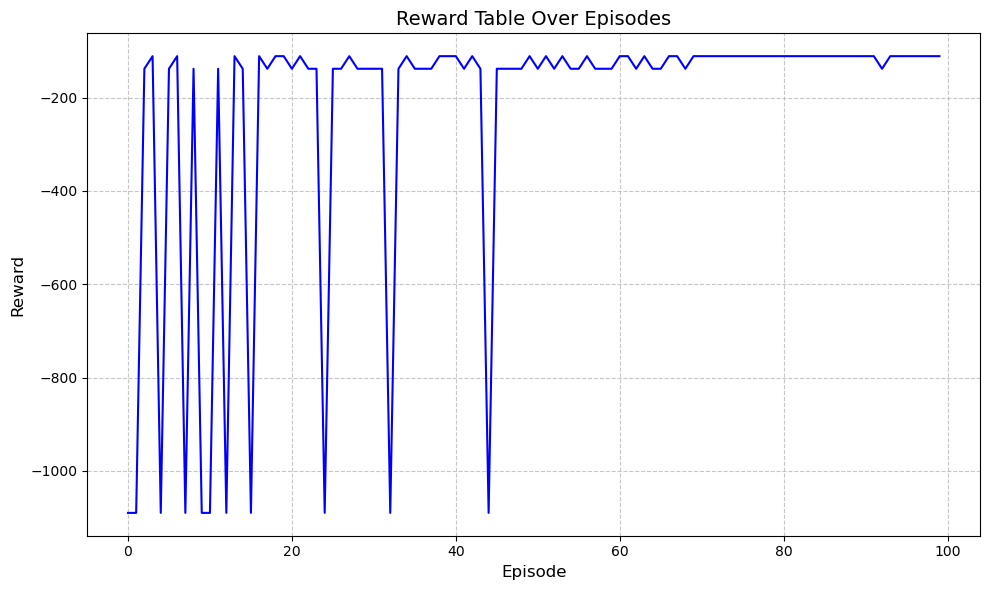

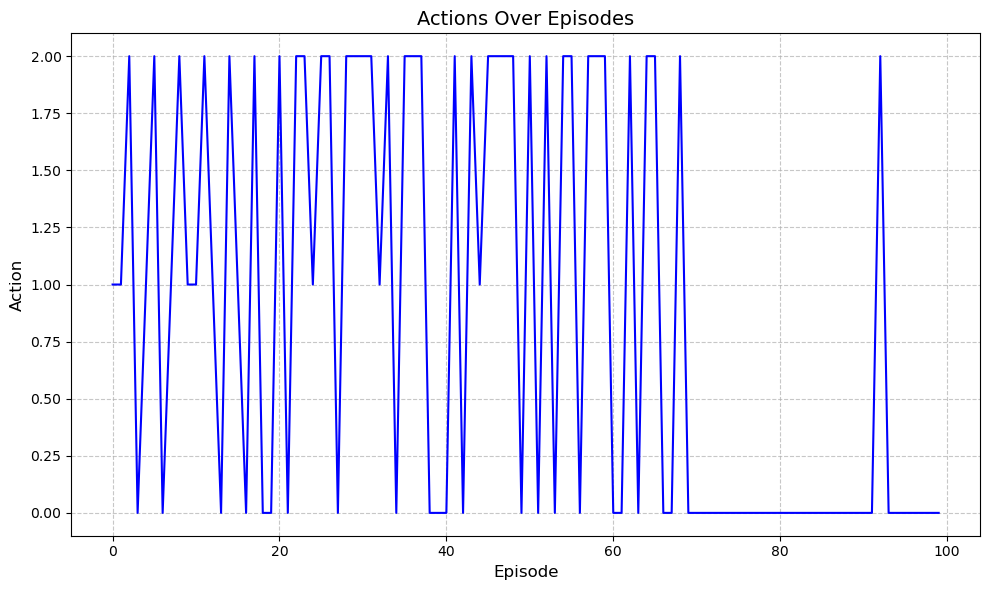

Reward table is:  [-1090.05, -1090.05, -1090.05, -111.36666666666666, -138.35, -1090.05, -138.35, -1090.05, -1090.05, -1090.05, -138.35, -1090.05, -138.35, -111.36666666666666, -138.35, -138.35, -111.36666666666666, -138.35, -1090.05, -138.35, -138.35, -1090.05, -138.35, -138.35, -138.35, -138.35, -138.35, -1090.05, -138.35, -138.35, -138.35, -138.35, -138.35, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -485.55, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -485.55, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -505.68333333333334, -28.4, -505.68333333333334, -28.4, -505.68333333333334, -505.68333333333334, -505.68333333333334, -28.4, -28.4, -28.4, -28.4, -505.68333333333334, -505.68333

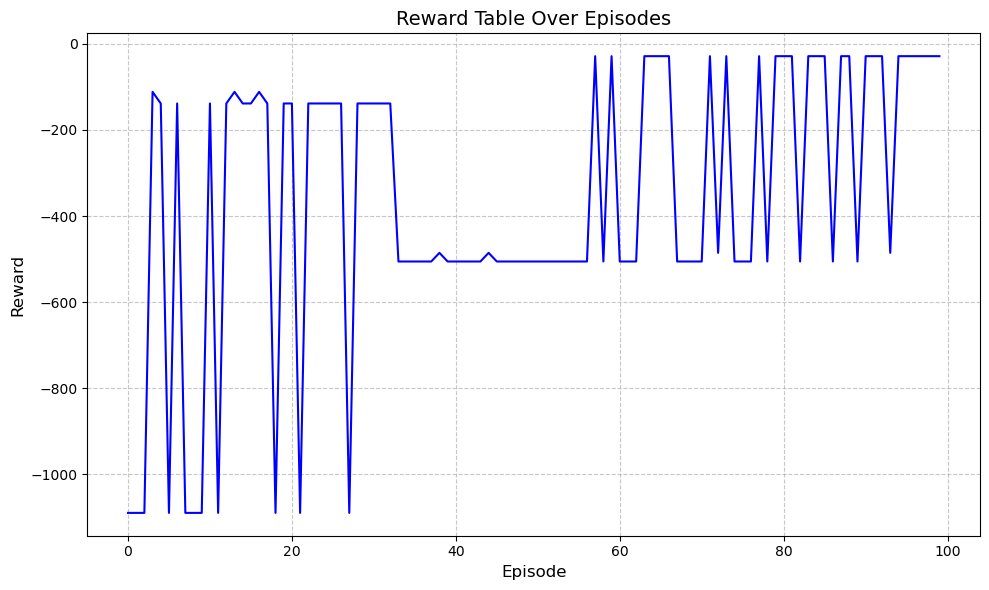

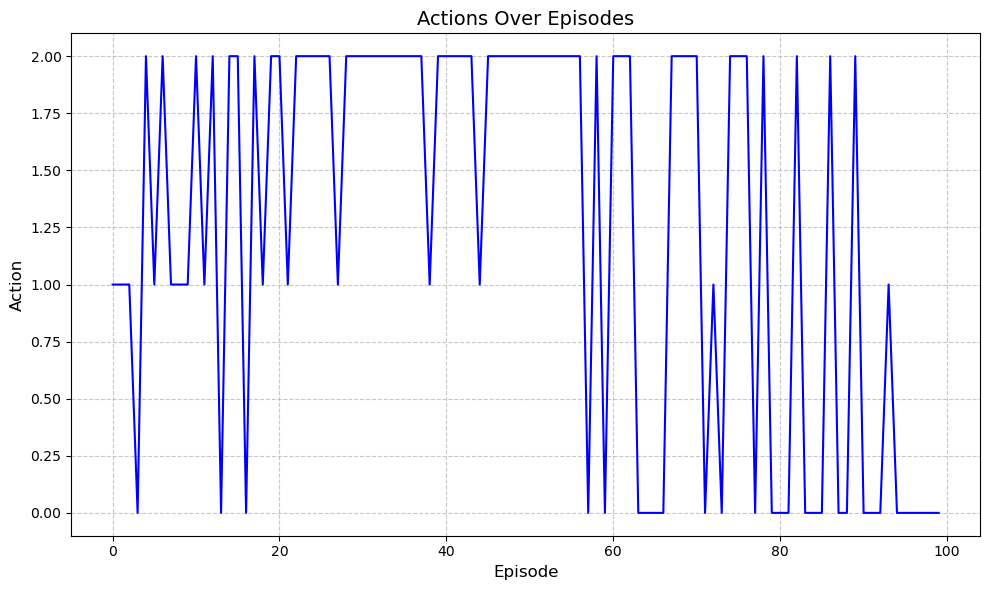

Reward table is:  [-28.4, -485.55, -28.4, -485.55, -485.55, -122.61666666666666, -104.25, -200.1, -122.61666666666666, -122.61666666666666, -122.61666666666666, -122.61666666666666, -122.61666666666666, -122.61666666666666, -122.61666666666666, -104.25, -122.61666666666666, -122.61666666666666, -122.61666666666666, -122.61666666666666, -104.25, -104.25, -104.25, -104.25, -122.61666666666666, -104.25, -104.25, -200.1, -104.25, -200.1, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -200.1, -104.25, -122.61666666666666, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -1

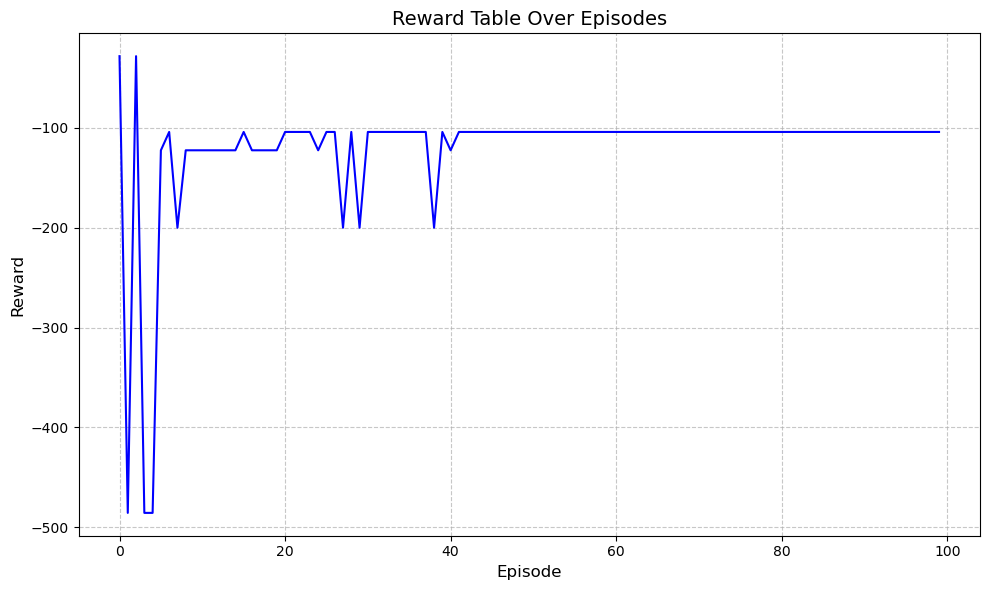

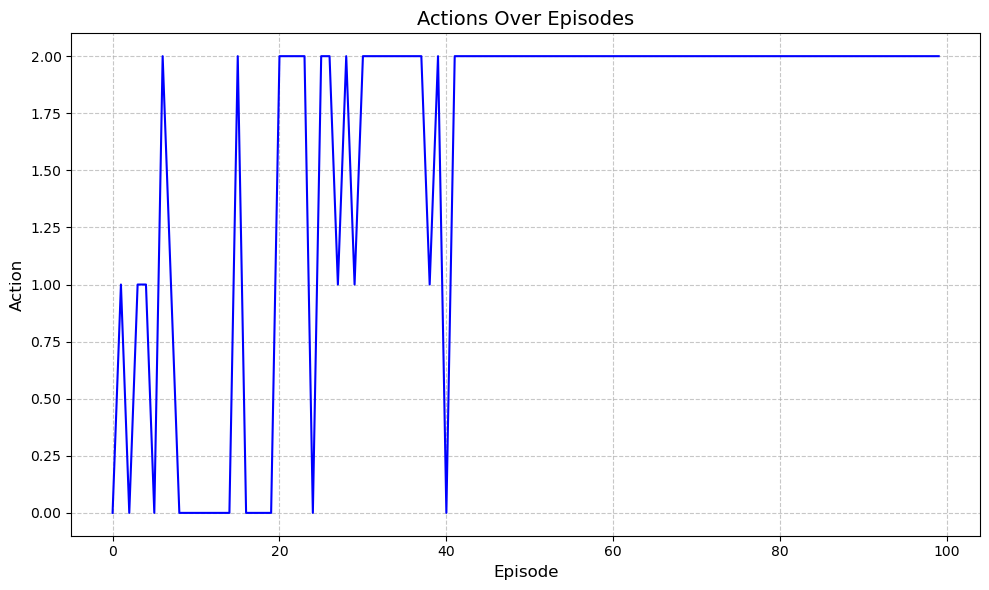

Reward table is:  [-104.25, -200.1, -122.61666666666666, -122.61666666666666, -104.25, -104.25, -104.25, -104.25, -200.1, -122.61666666666666, -104.25, -200.1, -122.61666666666666, -104.25, -122.61666666666666, -122.61666666666666, -104.25, -122.61666666666666, -122.61666666666666, -200.1, -104.25, -104.25, -104.25, -104.25, -122.61666666666666, -122.61666666666666, -122.61666666666666, -104.25, -122.61666666666666, -122.61666666666666, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -200.1, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -122.61666666666666, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25, -104.25,

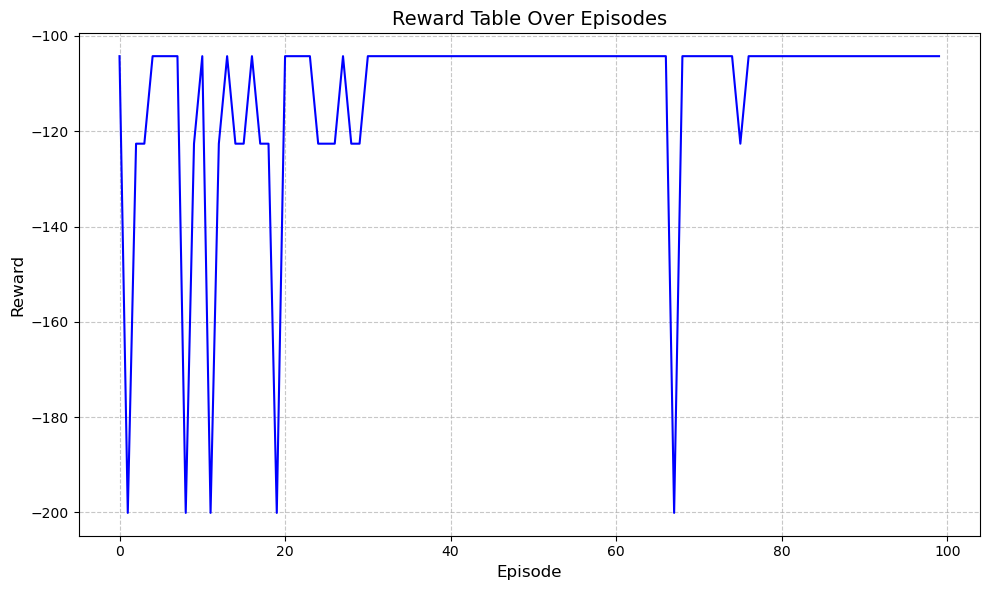

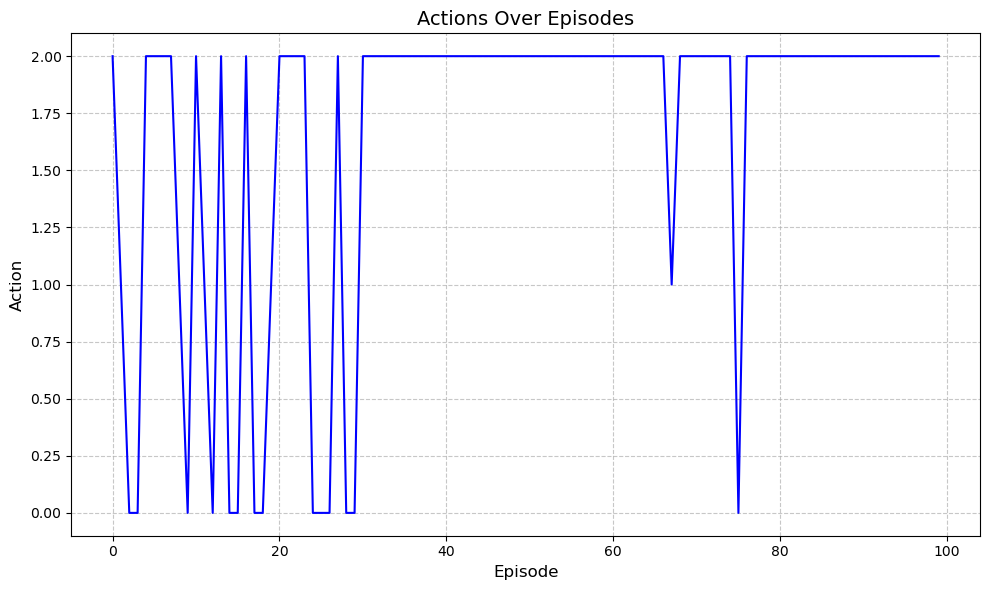

In [10]:
for learning_rate in learning_rate_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": learning_rate,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=0, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    model.learn(total_timesteps=100)  # Example: 100 total timesteps

    env.close()

ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host

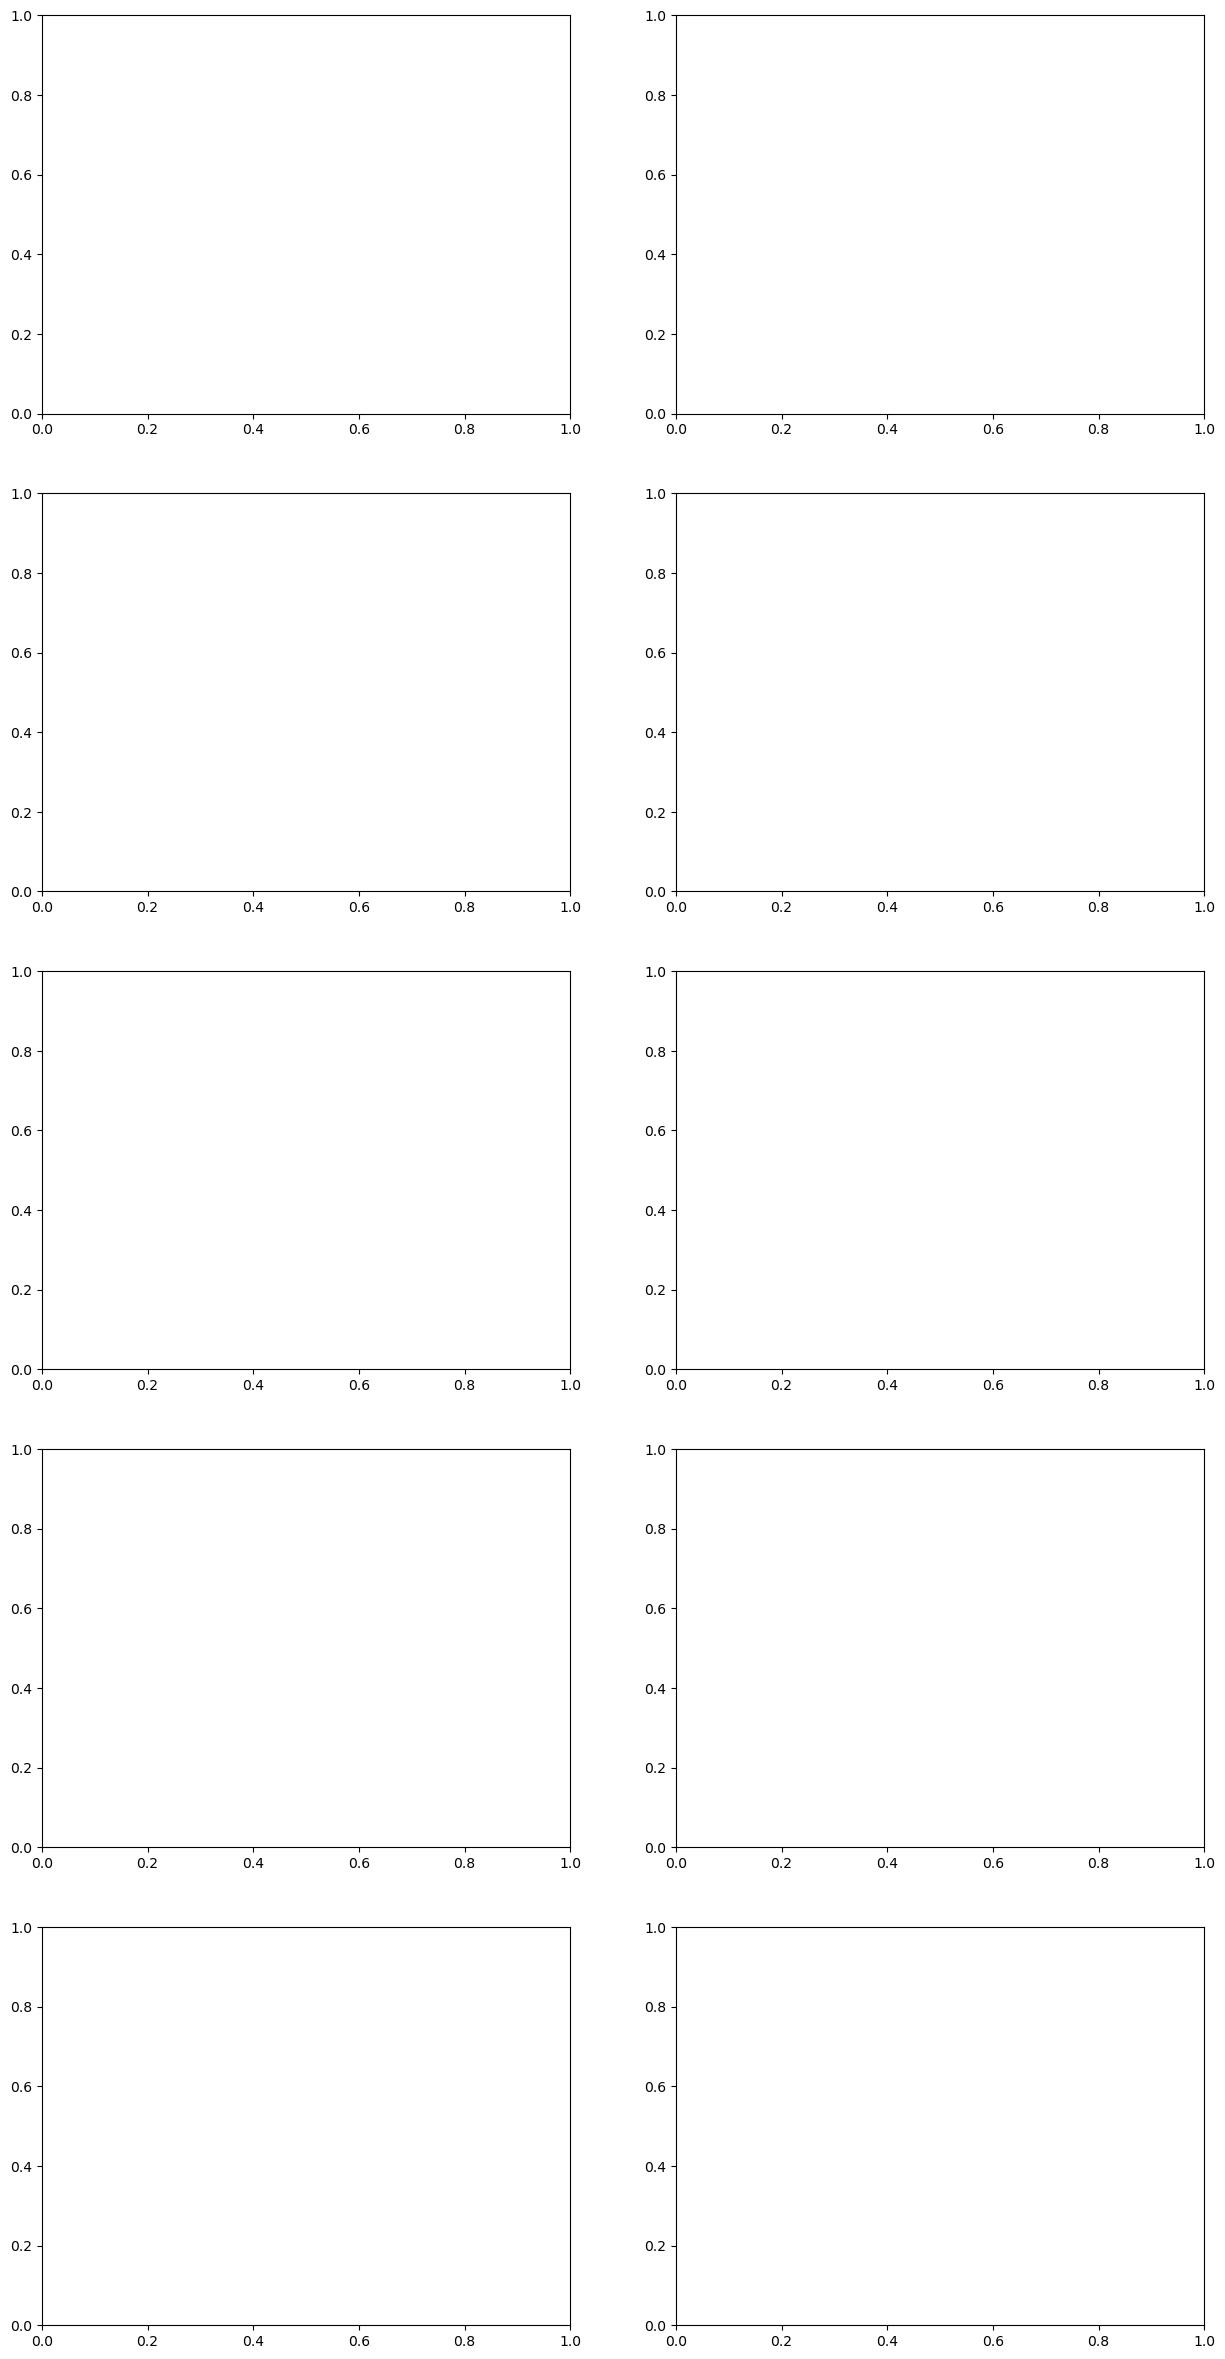

In [17]:
import matplotlib.pyplot as plt
import numpy as np

learning_rate_range = np.linspace(1e-4, 1e-2, 10)  # Example range for learning_rate
gamma = 0.95  # Constant value for gamma

# Set up subplots
num_plots = len(learning_rate_range)
num_cols = 2  # Number of columns for subplots
num_rows = num_plots // num_cols + (num_plots % num_cols > 0)

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 6*num_rows))

# Flatten the axes if there's only one row
if num_rows == 1:
    axs = [axs]

for i, learning_rate in enumerate(learning_rate_range):
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": learning_rate,
    }

    # Create the model (You might need to replace this line with your actual model creation)
    model = PPO("MlpPolicy", env, verbose=0, n_steps=10, batch_size=10, **tuned_params)

    # Train the model (You might need to replace this line with your actual training loop)
    model.learn(total_timesteps=10)  # Example: 100 total timesteps

    # Plot the reward table for the current episode
    ax = axs[i // num_cols][i % num_cols]
    ax.plot(env.reward_table, color='blue', linestyle='-')
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Reward', fontsize=12)
    ax.set_title(f'Reward Table Over Episodes (Learning Rate: {learning_rate})', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()
